In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('weight-height.csv')

In [3]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
df.shape

(10000, 3)

In [5]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [6]:
import seaborn as sns

<Axes: xlabel='Height', ylabel='Count'>

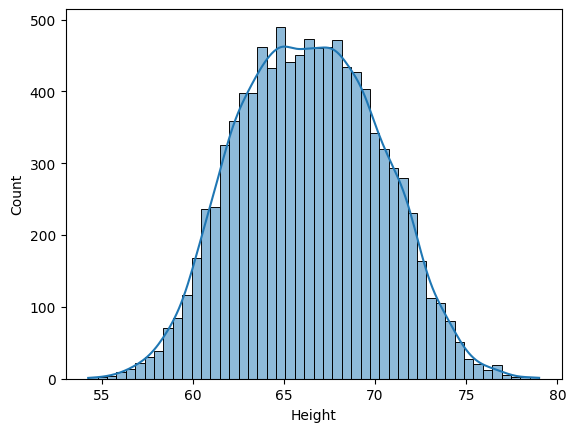

In [7]:
sns.histplot(df['Height'],kde=True)

<Axes: xlabel='Height'>

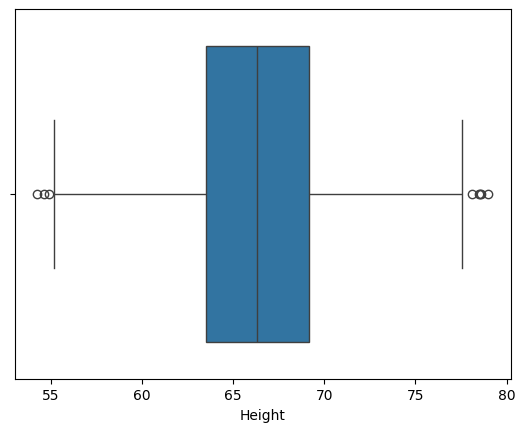

In [10]:
sns.boxplot(x=df['Height'])

In [11]:
upper_limit = df['Height'].quantile(0.98)
upper_limit

np.float64(73.98591718768152)

In [12]:
lower_limit = df['Height'].quantile(0.03)
lower_limit

np.float64(59.531091146317436)

In [13]:
new_df = df[(df['Height'] <= 73.98) & (df['Height'] >= 59.53)] 

In [15]:
new_df['Height'].describe()

count    9499.000000
mean       66.436523
std         3.443143
min        59.531162
25%        63.732307
50%        66.367540
75%        69.083828
max        73.976005
Name: Height, dtype: float64

In [16]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

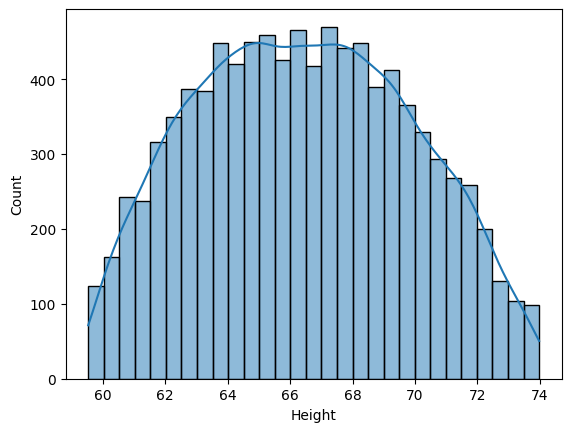

In [17]:
sns.histplot(new_df['Height'],kde=True)

<Axes: xlabel='Height'>

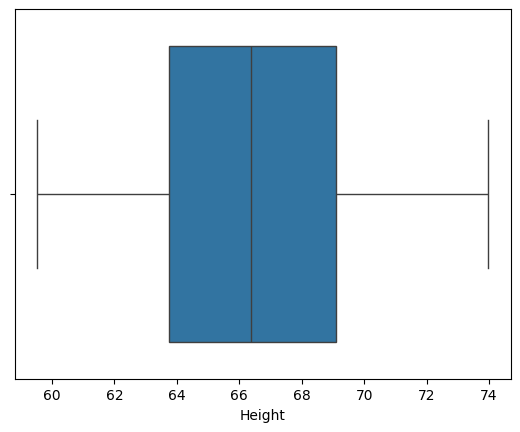

In [18]:
sns.boxplot(x=new_df['Height'])

In [19]:
# capping --> Winsorization
df['Height'] = np.where(df['Height'] >= upper_limit,
                       upper_limit,
                       np.where(df['Height'] <= lower_limit,
                               lower_limit,
                               df['Height']))

In [20]:
df.shape

(10000, 3)

In [21]:
df['Height'].describe()

count    10000.000000
mean        66.381103
std          3.719480
min         59.531091
25%         63.505620
50%         66.318070
75%         69.174262
max         73.985917
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

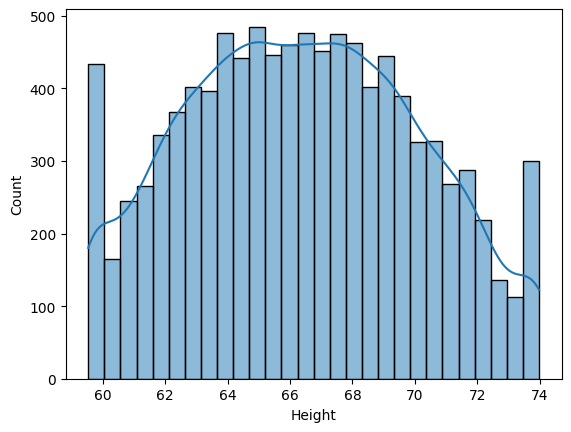

In [22]:
sns.histplot(df['Height'],kde=True)

<Axes: xlabel='Height'>

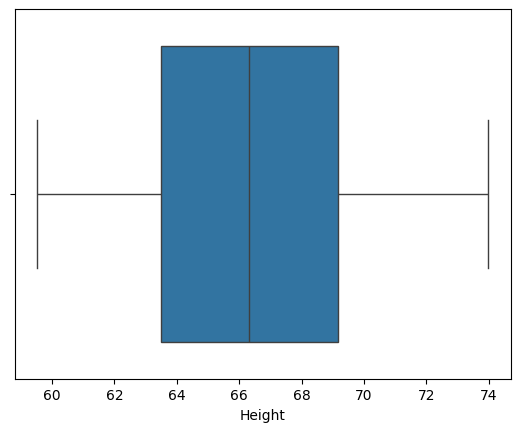

In [23]:
sns.boxplot(x=df['Height'])